In [1]:
from datasets import load_dataset
import os
# import pytorch_lightning as py
import torch.utils.data as data
from torch.utils.data import DataLoader, ConcatDataset
import torch
import pandas as pd
import gzip
# import glob
import tarfile
from PIL import Image
import io
from scipy.io import loadmat 
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv
import numpy as np
from torchvision import transforms
import torch.nn as nn
from torchsummary import summary
import piq
import random
import time

In [2]:
if torch.cuda.is_available():
    print(f"running cuda on device: {torch.cuda.current_device()}")
    device = torch.device("cuda")    
else:
    print(f"no cuda device found")
    device = torch.device("cpu")    


running cuda on device: 0


# Dataset

In [3]:
class DepthDataSet(data.Dataset):
    def __init__(self,images_path,depth_path,transform=None):
        self.image_path = images_path
        self.depth_path = depth_path
        self.transform = transform

        self.image_files = ([
            f for f in os.listdir(self.image_path)
            if os.path.isfile(os.path.join(self.image_path,f))
            ])
        self.depth_files = ([
            f for f in os.listdir(self.depth_path)
            if os.path.isfile(os.path.join(self.depth_path,f))
            ])

    def __len__(self):
        return len(self.depth_files)
    
    def __getitem__(self, index):
        image_file = self.image_files[index]
        depth_file = self.depth_files[index]
        
        img_path = os.path.join(self.image_path, image_file)
        dpth_path = os.path.join(self.depth_path, depth_file)


        image = Image.open(img_path)
        image = self.transform(image)


        mat_file = loadmat(dpth_path)
        depth = mat_file.get("Position3DGrid")
        depth = depth[:,:,3]
        depth = np.log1p(depth)

        depth = cv.resize(depth, (1704,2272), interpolation=cv.INTER_CUBIC)
        depth = cv.normalize(depth, None, 0, 255, cv.NORM_MINMAX)
        depth = depth.astype(np.uint8)

        depth = np.expand_dims(depth,axis=2)

        depth = torch.from_numpy(depth).permute(2,0,1).float() / 255.0
        return image, depth

        

In [4]:
train_dataset = DepthDataSet(images_path='./data/train/imgs',depth_path='./data/train/depths',transform=transforms.ToTensor())
val_dataset = DepthDataSet(images_path='./data/test/imgs',depth_path='./data/test/depths',transform=transforms.ToTensor())

In [5]:
train_dataloader = DataLoader(train_dataset,batch_size=8,shuffle=True)
val_dataloader = DataLoader(val_dataset,batch_size=8,shuffle=True)

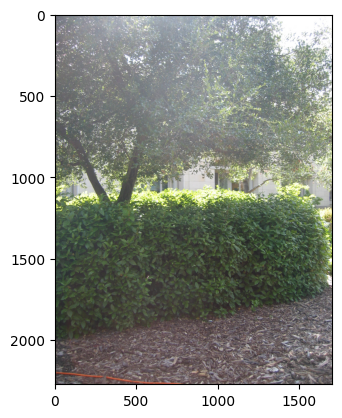

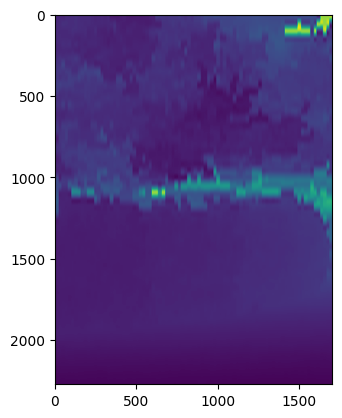

In [6]:
index=388
image,depth = train_dataset[index]
image = image.cpu().permute(1,2,0).numpy()
plt.imshow(image)
plt.show()

depth = depth.cpu().permute(1,2,0).numpy()
plt.imshow(depth)
plt.show()

# Image manipulation

In [7]:
def equalizeDepth(depth):
    depth = depth.cpu().permute(1,2,0).numpy()
    depth = ((depth-depth.min()) / (depth.max()-depth.min())) * 255
    depth = depth.astype(np.uint8)
    depth = cv.equalizeHist(depth)

    depth = np.expand_dims(depth, axis=0)

    depth = torch.tensor(depth)
    depth = depth.float()/255.0

    return depth

In [8]:
def fourierTransform(image, amount=20):
    b,g,r = image[:,:,0],image[:,:,1],image[:,:,2]
    def channelFourier(channel):
        image_transformed = np.fft.fft2(channel)
        transformed_shifted = np.fft.fftshift(image_transformed)
        # print(np.shape(transformed_shifted))
        (rows, cols) = transformed_shifted.shape
        crow, ccol = rows//2,cols//2

        area = amount
        mask = np.ones((rows,cols),np.uint8)
        mask[crow-area:crow+area, ccol-area:ccol+area] = 0
        transformed_shifted_filtered = transformed_shifted * mask
        # plt.imshow(20 * np.log(np.abs(transformed_shifted_filtered)))
        # plt.show()

        shift_back = np.fft.ifftshift(transformed_shifted_filtered)
        channel = np.fft.ifft2(shift_back)
        channel = np.abs(channel)
        channel = (channel - np.min(channel)) / (np.max(channel) - np.min(channel))

        return channel
    
    b = channelFourier(b)
    g = channelFourier(g)
    r = channelFourier(r)

    image = np.dstack((b,g,r))
    return image

In [9]:
def equalizeImage(image):
    image = image.cpu().permute(1,2,0).numpy()

    # gamma = .2
    # image = np.power(image,gamma)
    # image = image
    print(image.max())
    image = ((image-image.min()) / (image.max()-image.min())) * 255


    # image = image.astype(np.uint8)

    image_lab = cv.cvtColor(image, cv.COLOR_RGB2LAB)
    l,a,b = cv.split(image_lab)


    l *= 2.55
    a += 128
    b += 128
    l = l.astype(np.uint8)
    a = a.astype(np.uint8)
    b = b.astype(np.uint8)
    #equalize luminance only
    l_equal = cv.equalizeHist(l)
    image_equal = cv.merge([l_equal,a,b])

    image = cv.cvtColor(image_equal, cv.COLOR_LAB2RGB)
    
    # b,g,r = cv.split(image)
    # b_eq = cv.equalizeHist(b)
    # g_eq = cv.equalizeHist(g)
    # r_eq = cv.equalizeHist(r)

    # image = cv.merge([b_eq,g_eq,r_eq])


    # image = fourierTransform(image,amount=fourier_amount)
    image = image/255.0
    image = torch.tensor(image).permute(2,0,1).to(dtype=torch.float32)
    # image = image.float()
    return image

## Test manipulation

1.0


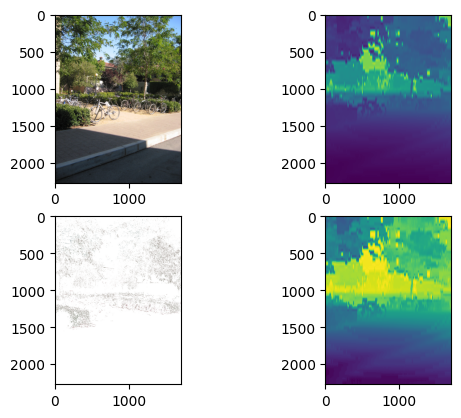

mean = 0.3883764147758484 : 0.242533877491951
std = 0.28340333700180054 : 0.19995714724063873
min = 0.0 : 0.0
max = 1.0 : 1.0


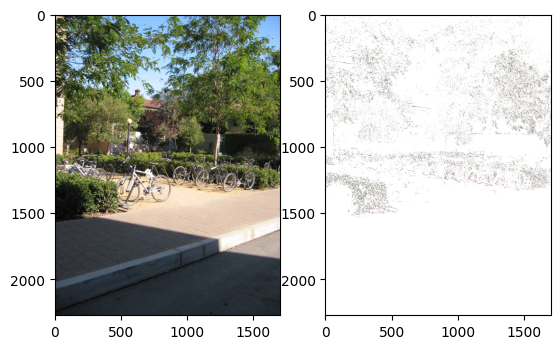

1.0


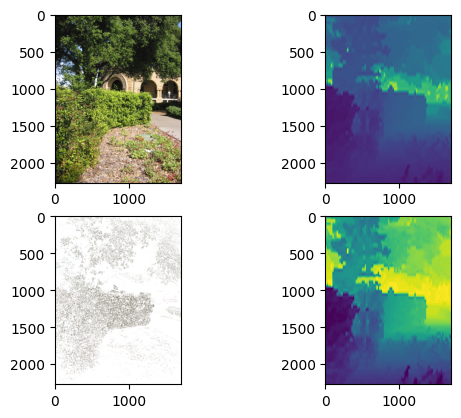

mean = 0.3701561987400055 : 0.2669878602027893
std = 0.2840137779712677 : 0.14997048676013947
min = 0.0 : 0.0
max = 1.0 : 0.9960784316062927


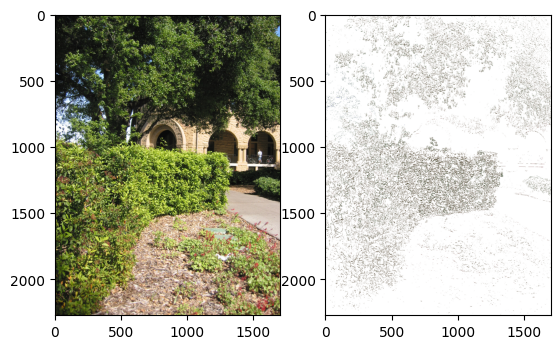

1.0


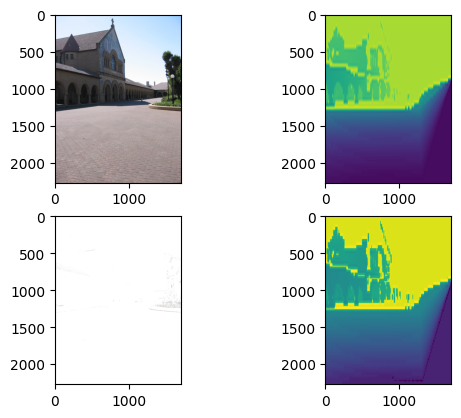

mean = 0.5820595622062683 : 0.502834677696228
std = 0.27264976501464844 : 0.3494338095188141
min = 0.0 : 0.0
max = 1.0 : 1.0


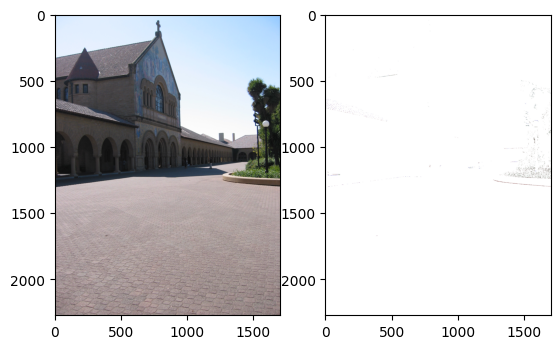

1.0


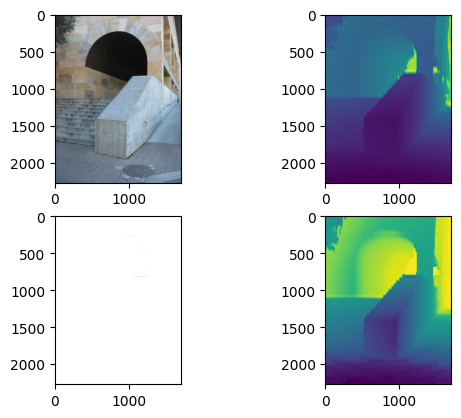

mean = 0.4988952577114105 : 0.2325143814086914
std = 0.20570826530456543 : 0.16739775240421295
min = 0.0 : 0.0
max = 1.0 : 0.9960784316062927


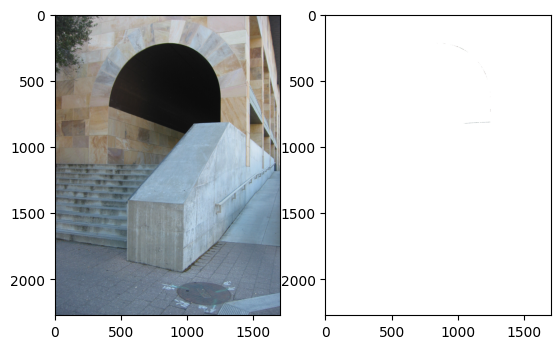

1.0


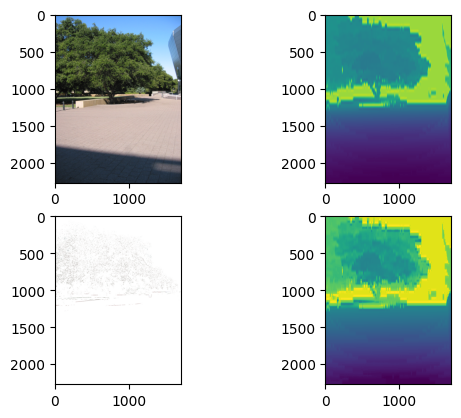

mean = 0.46135184168815613 : 0.3995140790939331
std = 0.28949812054634094 : 0.2865845263004303
min = 0.0 : 0.0
max = 1.0 : 1.0


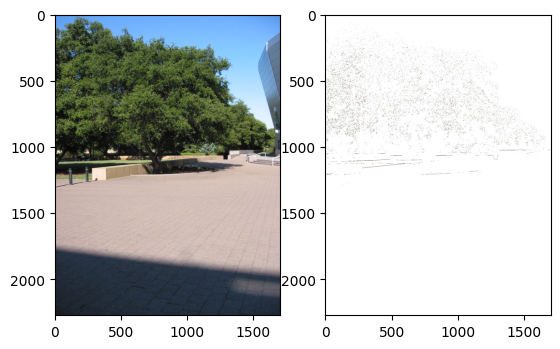

In [10]:

random.seed(time.time())
list = [i for i in range(400)]
indices = random.sample(list,5)
for index in indices:
    image,depth_map = train_dataset[index]
    equalized_image = equalizeImage(image)
    equalized_depth_map = equalizeDepth(depth_map)
    

    fig,axs = plt.subplots(2,2)
    image = image.cpu().permute(1,2,0).numpy()
    axs[0,0].imshow(image)
    axs[1,0].imshow(equalized_image.cpu().permute(1,2,0).numpy())
    
    depth_map = depth_map.cpu().permute(1,2,0).numpy()
    axs[0,1].imshow(depth_map)
    axs[1,1].imshow(equalized_depth_map.cpu().permute(1,2,0).numpy())

    plt.show()

    print(f"mean = {np.mean(image)} : {np.mean(depth_map)}")
    print(f"std = {np.std(image)} : {np.std(depth_map)}")
    print(f"min = {np.min(image)} : {np.min(depth_map)}")
    print(f"max = {np.max(image)} : {np.max(depth_map)}")
    fig,axs = plt.subplots(1,2)
    axs[0].imshow(image)
    axs[1].imshow(equalized_image.cpu().permute(1,2,0).numpy())
    plt.show()
    
del list

# AE Model

In [11]:
class EncoderDecoder(nn.Module):
    def __init__(self):
        super(EncoderDecoder,self).__init__()
        #bias for skip
        self.bias4 = nn.Parameter(torch.tensor(0.75))
        self.bias3 = nn.Parameter(torch.tensor(0.75))
        self.bias2 = nn.Parameter(torch.tensor(0.75))
        self.bias1 = nn.Parameter(torch.tensor(0.75))

        self.relu4 = nn.LeakyReLU(0.01)
        self.relu3 = nn.LeakyReLU(0.01)
        self.relu2 = nn.LeakyReLU(0.01)
        self.relu1 = nn.LeakyReLU(0.01)

        #encoder
        self.encoder_conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3,out_channels=12,kernel_size=3,stride=2,padding=1),
            nn.BatchNorm2d(12),
            nn.LeakyReLU(0.01),
        )
        
        self.encoder_conv2 = nn.Sequential(
            nn.Conv2d(in_channels=12,out_channels=24,kernel_size=5,stride=2,padding=1),
            nn.BatchNorm2d(24),
            nn.LeakyReLU(0.01),
        )

        self.encoder_conv3 = nn.Sequential(
            nn.Conv2d(in_channels=24,out_channels=32,kernel_size=7,stride=2,padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.01),
        )

        self.encoder_conv4 = nn.Sequential(
            nn.Conv2d(in_channels=32,out_channels=48,kernel_size=5,stride=2,padding=1),
            nn.BatchNorm2d(48),
            nn.LeakyReLU(0.01),
        )

        self.encoder_conv5 = nn.Sequential(
            nn.Conv2d(in_channels=48,out_channels=64,kernel_size=3,stride=1,padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.01),
        )

        #decoder
        self.decoder_conv1 = nn.Sequential(
            nn.ConvTranspose2d(in_channels=64,out_channels=48,kernel_size=3,stride=1,padding=1),
            # nn.AdaptiveAvgPool2d((143, 107)),
            nn.BatchNorm2d(48),
            # nn.ReLU()
        )

        self.decoder_conv2 = nn.Sequential(
            nn.ConvTranspose2d(in_channels=48,out_channels=32,kernel_size=5,stride=2,padding=1),
            nn.AdaptiveAvgPool2d((282,211)),
            nn.BatchNorm2d(32),
            # nn.ReLU()
        )

        self.decoder_conv3 = nn.Sequential(
            nn.ConvTranspose2d(in_channels=32,out_channels=24,kernel_size=7,stride=2,padding=1),
            # nn.AdaptiveAvgPool2d((567,425)),
            nn.BatchNorm2d(24),
            # nn.ReLU()
        )

        self.decoder_conv4 = nn.Sequential(
            nn.ConvTranspose2d(in_channels=24,out_channels=12,kernel_size=5,stride=2,padding=1),
            nn.AdaptiveAvgPool2d((1136,852)),
            nn.BatchNorm2d(12),
            # nn.ReLU()
        )

        self.decoder_conv4_5 = nn.Sequential(
            nn.ConvTranspose2d(in_channels=12,out_channels=3,kernel_size=3,stride=1,padding=1),
            # nn.AdaptiveAvgPool2d((1136,852)),
            nn.BatchNorm2d(3),
            nn.LeakyReLU(0.01),
        )

        self.decoder_conv5 = nn.Sequential(
            nn.ConvTranspose2d(in_channels=3,out_channels=1,kernel_size=3,stride=2,padding=1),
            nn.AdaptiveAvgPool2d((2272,1704)),
            nn.Sigmoid()
        )


    def forward(self,x):
        encoder_x1 = self.encoder_conv1(x) #12
        encoder_x2 = self.encoder_conv2(encoder_x1) #24
        encoder_x3 = self.encoder_conv3(encoder_x2) #36
        encoder_x4 = self.encoder_conv4(encoder_x3) #48
        encoder_x5 = self.encoder_conv5(encoder_x4) #64

        #layer 1
        x_d = self.decoder_conv1(encoder_x5)
        
        x_d = x_d + (encoder_x4 * self.bias4)
        x_d = self.relu4(x_d)
        
        #layer 2
        x_d = self.decoder_conv2(x_d)
        x_d = x_d + (encoder_x3 * self.bias3)
        x_d = self.relu3(x_d)
        
        #layer 3
        x_d = self.decoder_conv3(x_d)

        x_d = x_d + (encoder_x2 * self.bias2)
        x_d = self.relu2(x_d)


        #layer 4
        x_d = self.decoder_conv4(x_d)
        x_d = x_d + (encoder_x1 * self.bias1)
        x_d = self.relu1(x_d)


        #layer 5
        x_d = self.decoder_conv4_5(x_d)

        x_d = self.decoder_conv5(x_d)

        return x_d


In [12]:
model = EncoderDecoder()
model.to(device)
summary(model,(3,2272, 1704))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1        [-1, 12, 1136, 852]             336
       BatchNorm2d-2        [-1, 12, 1136, 852]              24
         LeakyReLU-3        [-1, 12, 1136, 852]               0
            Conv2d-4         [-1, 24, 567, 425]           7,224
       BatchNorm2d-5         [-1, 24, 567, 425]              48
         LeakyReLU-6         [-1, 24, 567, 425]               0
            Conv2d-7         [-1, 32, 282, 211]          37,664
       BatchNorm2d-8         [-1, 32, 282, 211]              64
         LeakyReLU-9         [-1, 32, 282, 211]               0
           Conv2d-10         [-1, 48, 140, 105]          38,448
      BatchNorm2d-11         [-1, 48, 140, 105]              96
        LeakyReLU-12         [-1, 48, 140, 105]               0
           Conv2d-13         [-1, 64, 140, 105]          27,712
      BatchNorm2d-14         [-1, 64, 1

# Training

In [13]:
def save_check(epoch, model, optimizer, loss, filename):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss
    }
    torch.save(checkpoint, filename)
    print(f'Saved model at epoch:{epoch+1}')

In [ ]:
    import kornia
    import pytorch_ssim
    def pyrdown(input_tensor: torch.Tensor, num_scales: int = 4):
        """ Creates a downscale pyramid for the input tensor. """
        output = [input_tensor]
        for _ in range(num_scales - 1):
            down = kornia.filters.blur_pool2d(output[-1], 3)
            output.append(down)
        return output





    class MultiLoss(nn.Module):
        def __init__(self):
            super(MultiLoss,self).__init__()

            self.grad_weight = nn.Parameter(torch.tensor(1.0))
            self.ssim_weight = nn.Parameter(torch.tensor(0.1))
            self.si_weight = nn.Parameter(torch.tensor(0.035))
            self.l1_weight = nn.Parameter(torch.tensor(0.2))
        
            self.l1Loss = nn.L1Loss()
            self.ssimLoss = kornia.losses.SSIMLoss(window_size=11)
            
        def SILoss(self, input1, input2):
            # Ensure no log(0) or log(negative)
            input1 = torch.clamp(input1, min=1e-6)
            input2 = torch.clamp(input2, min=1e-6)
            log_diff = torch.log(input1 ) - torch.log(input2)
            factor = log_diff.numel()
            loss = torch.sum(log_diff ** 2) / factor - (torch.sum(log_diff) ** 2) / (factor ** 2)
            return torch.clamp(loss, min=0.0)
        
        def gradLoss(self, input1, input2):
            input1_pyr = pyrdown(input1, 3)
            input2_pyr = pyrdown(input2, 3)
        
            grad_loss = torch.tensor(0, dtype=input1.dtype, device=input1.device)
            for input1_down, input2_down in zip(input1_pyr, input2_pyr):
                input2_grad = kornia.filters.spatial_gradient(input2_down)
        
                mask_not_zero = input2_grad != 0
                mask_down_b = mask_not_zero.all(dim=1, keepdim=True)
        
                input1_grad = kornia.filters.spatial_gradient(input1_down).masked_select(mask_down_b)
        
                if input1_grad.numel() == 0:  # Avoid NaN
                    continue
                
                grad_error = torch.abs(input1_grad - input2_grad.masked_select(mask_down_b))
                grad_loss += torch.mean(grad_error)
        
            return grad_loss
        
        def forward(self, input1, input2):
            l_grad = self.gradLoss(input1, input2) * torch.sigmoid(self.grad_weight)
            siloss = self.SILoss(input1, input2) * torch.sigmoid(self.si_weight)
            l1_loss = self.l1Loss(input1,input2) * torch.sigmoid(self.l1_weight) 
            ssim_loss = (1-self.ssimLoss(input1,input2)) * torch.sigmoid(self.ssim_weight)

            loss = (
                # siloss + 
                # l_grad + 
                l1_loss + 
                ssim_loss 
            )

            # print(f"SI weight: {si_weight:.4f}, Grad weight: {l_grad:.4f}")
            # print(f"[Loss Breakdown] L1: {l1_loss.item():.4f}, SSIM: {ssim_loss.item():.4f}, SI: {siloss.item():.4f}, Grad: {l_grad.item():.4f}")
            print(f"[Loss Breakdown] L1: {l1_loss.item():.4f}, SSIM: {ssim_loss.item():.4f}")


            return loss


In [15]:
def computeAndShowTestImage(image_path,model):
    image = Image.open(image_path)
    image = image.resize((1704, 2272),3)

    fig,axs = plt.subplots(1,2)
    axs[0].imshow(image)



    transform = transforms.ToTensor()
    image = transform(image)
    # image = np.expand_dims(image,axis=0)

    # image = equalizeImage(image)
    # image = image.unsqueeze(0)

    model.eval()
    image = image.cpu().detach().unsqueeze(0)
    depth = model(image.to(device))

    # depth.to('cpu')
    
    axs[1].imshow(depth[0].cpu().permute(1,2,0).detach().numpy())
    plt.show()
        

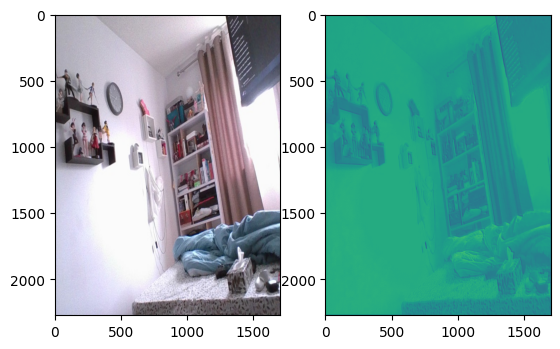

In [16]:
computeAndShowTestImage('./data/webcam/test.jpg',model)

In [17]:
from skimage.metrics import structural_similarity as ssim
def structuralSimilarityIndex(input1, input2):
    input1 = input1.squeeze().cpu().numpy()
    input2 = input2.squeeze().cpu().numpy()
    # print(input1.min())
    input1 = (input1 * 255).astype(np.uint8)
    input2 = (input2 * 255).astype(np.uint8)

    accuracy, diff_map = ssim(input1,input2,full=True)
    return accuracy, diff_map

    

In [18]:
def compareResults(model,dataloader, num_batches=3):
    i = 0
    for images, depths in dataloader:
        if i>=num_batches:
            break
        
        # equalized_images = np.array([equalizeImage(img) for img in images])      
        # equalized_images = np.array([equalizeImage(img) for img in images])      
        depths = np.array([equalizeDepth(dpth) for dpth in depths])

        # equalized_images = torch.from_numpy(equalized_images)
        depths = torch.from_numpy(depths)
        depths
        # print(images)
        with torch.no_grad():
            result = model(images.to(device))

            result = result.to("cpu")
            result = result.detach()
        for i in range(result.shape[0]):
            fig, axs = plt.subplots(1,4)
            axs[0].imshow(images[i].permute(1,2,0))

            axs[1].imshow(depths[i].permute(1,2,0))

            depth = np.array(result[i].permute(1,2,0)*255,dtype=np.uint8)
            
            axs[2].imshow(depth)

            # print(f"result = mean:{np.mean(depth)}\nvar:{np.var(depth)}\nmax:{np.max(depth)}")
            
            # print(f"depth = mean:{depths[i].mean().item()}\nvar:{depths[i].var().item()}\nmax:{depths[i].max().item()}")
            # print(depths[i]-result[i])
            accuracy, diff_map = structuralSimilarityIndex(depths[i],result[i])
            print(f"accuracy:{accuracy}")
            axs[3].imshow(diff_map)
            
            plt.show()
        i+=1
        

In [19]:
def train(model,train_dataloader,optimizer, criterion, scheduler, epochs=range(2), model_name="encoder_decoder"):
    for epoch in epochs:
        model.train()
        total_loss = 0.0
        batch_num = 0
        for data,depth_data in (train_dataloader):

            batch_num+=1
            
            inputs = data
            ground_truth = depth_data

            # inputs = np.array([equalizeImage(img) for img in inputs])      

            ground_truth = np.array([equalizeDepth(depths) for depths in ground_truth])
            
            # inputs = torch.from_numpy(inputs)
            ground_truth = torch.from_numpy(ground_truth)
            
            inputs = inputs.to(device)
            ground_truth = ground_truth.to(device)

            optimizer.zero_grad()
            result = model(inputs)
            
            loss = criterion(result,ground_truth)

            loss.backward()
            optimizer.step()
            
            curr_loss = loss.item()
            total_loss+= curr_loss

            print("Batch:{:3d}/{:3d}{:10}Loss{:10f}{:10}{:2d}/{:2d}".format(batch_num,len(train_dataloader),"",curr_loss,"",epoch+1,epochs.stop))
            
        scheduler.step()
        filename ="./models/checkpoints"
        save_check(epoch,model,optimizer,criterion,f"{filename}/{model_name}_{epoch}.pth")

        model.eval()
        with torch.no_grad():
            computeAndShowTestImage('./data/webcam/test.jpg',model)
            compareResults(model,train_dataloader,num_batches=1)


        

In [20]:
def load_check(filename, model, optimizer):
    checkpoint = torch.load(filename, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint['epoch']
    loss = checkpoint['loss']
    
    print(f'Loaded model from epoch:{epoch+1}')
    
    return epoch, loss

In [25]:
# loss = MultiLoss()
# loss = nn.L1Loss()
loss = MultiLoss()



In [26]:
optimizer = torch.optim.Adam(list(model.parameters()) + list(loss.parameters()), lr=0.01)
# optimizer = torch.optim.Adam(list(model.parameters()) + list(loss.parameters()), lr=0.01)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5,gamma=0.1)

In [27]:
# load_check("./models/checkpoints/implemented_only_make3d_19.pth", model, optimizer)

[Loss Breakdown] L1: 0.9319, SSIM: 0.5025
Batch:  1/ 50          Loss  1.434397           1/10
[Loss Breakdown] L1: 0.8752, SSIM: 0.4985
Batch:  2/ 50          Loss  1.373705           1/10
[Loss Breakdown] L1: 0.7972, SSIM: 0.4947
Batch:  3/ 50          Loss  1.291916           1/10
[Loss Breakdown] L1: 0.9107, SSIM: 0.4954
Batch:  4/ 50          Loss  1.406111           1/10
[Loss Breakdown] L1: 0.7667, SSIM: 0.4837
Batch:  5/ 50          Loss  1.250428           1/10
[Loss Breakdown] L1: 0.7522, SSIM: 0.4786
Batch:  6/ 50          Loss  1.230873           1/10
[Loss Breakdown] L1: 0.7164, SSIM: 0.4742
Batch:  7/ 50          Loss  1.190636           1/10
[Loss Breakdown] L1: 0.7584, SSIM: 0.4707
Batch:  8/ 50          Loss  1.229116           1/10
[Loss Breakdown] L1: 0.7673, SSIM: 0.4694
Batch:  9/ 50          Loss  1.236612           1/10
[Loss Breakdown] L1: 0.6836, SSIM: 0.4640
Batch: 10/ 50          Loss  1.147554           1/10
[Loss Breakdown] L1: 0.6721, SSIM: 0.4586
Batch: 1

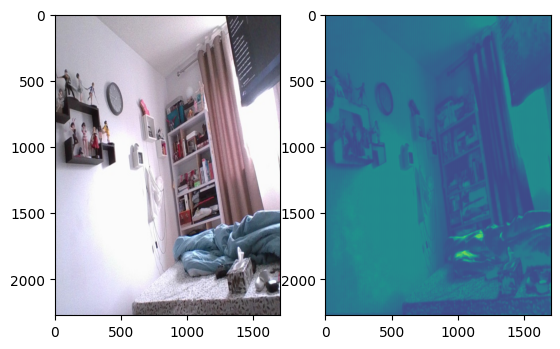

accuracy:0.03799073313931367


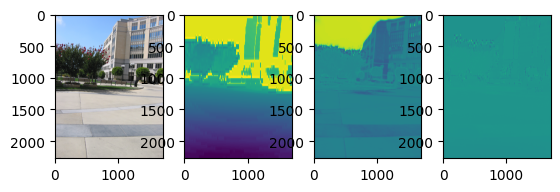

accuracy:0.0425626922430872


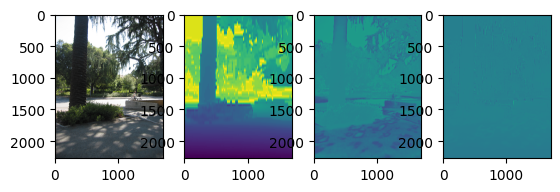

accuracy:0.04084089036846571


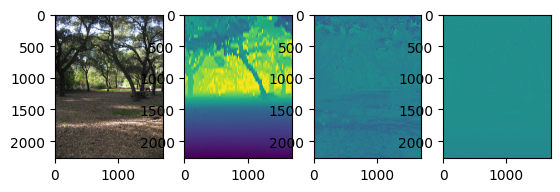

accuracy:0.04625922213374385


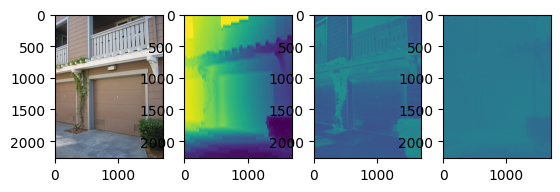

accuracy:0.043445758493159854


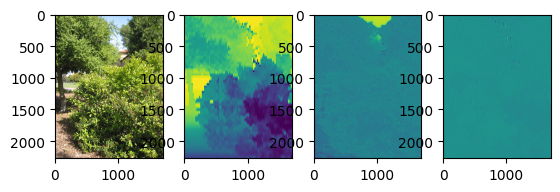

accuracy:0.04647017519803177


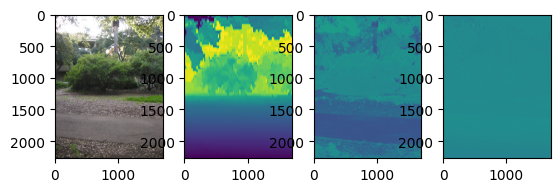

accuracy:0.03956800241183501


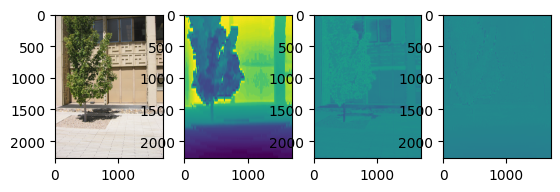

accuracy:0.039700600366895315


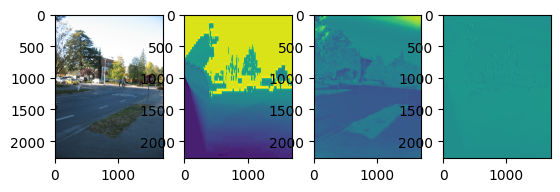

[Loss Breakdown] L1: 0.3899, SSIM: 0.2845
Batch:  1/ 50          Loss  0.674379           2/10
[Loss Breakdown] L1: 0.4226, SSIM: 0.2760
Batch:  2/ 50          Loss  0.698571           2/10
[Loss Breakdown] L1: 0.3766, SSIM: 0.2769
Batch:  3/ 50          Loss  0.653514           2/10
[Loss Breakdown] L1: 0.3836, SSIM: 0.2701
Batch:  4/ 50          Loss  0.653659           2/10
[Loss Breakdown] L1: 0.3628, SSIM: 0.2645
Batch:  5/ 50          Loss  0.627290           2/10
[Loss Breakdown] L1: 0.3803, SSIM: 0.2591
Batch:  6/ 50          Loss  0.639451           2/10
[Loss Breakdown] L1: 0.3649, SSIM: 0.2571
Batch:  7/ 50          Loss  0.621995           2/10
[Loss Breakdown] L1: 0.3781, SSIM: 0.2513
Batch:  8/ 50          Loss  0.629412           2/10
[Loss Breakdown] L1: 0.3518, SSIM: 0.2476
Batch:  9/ 50          Loss  0.599307           2/10
[Loss Breakdown] L1: 0.3638, SSIM: 0.2387
Batch: 10/ 50          Loss  0.602534           2/10
[Loss Breakdown] L1: 0.3454, SSIM: 0.2342
Batch: 1

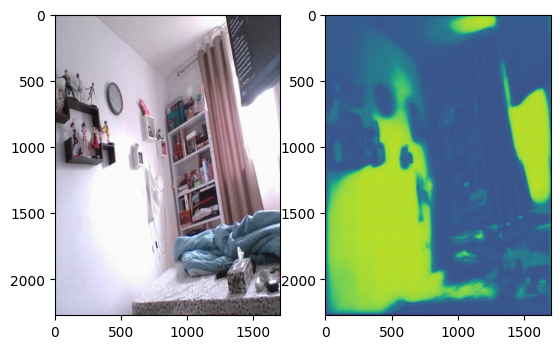

accuracy:0.026243783308508975


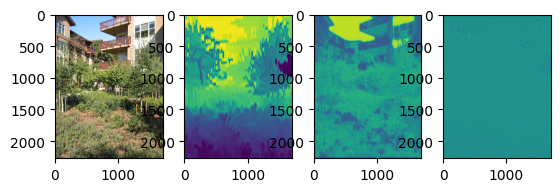

accuracy:0.027881125371248382


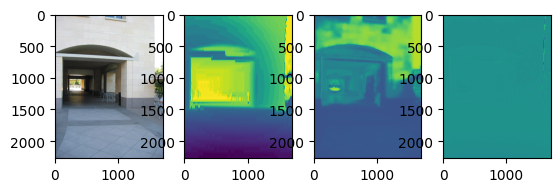

accuracy:0.030671101093143006


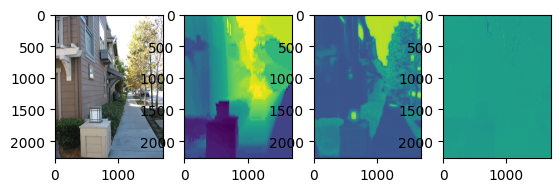

accuracy:0.024692777581767605


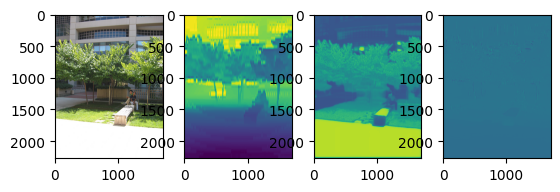

accuracy:0.026575125744892215


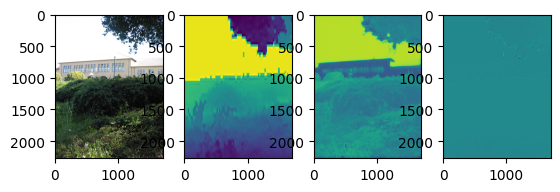

accuracy:0.03007557394830386


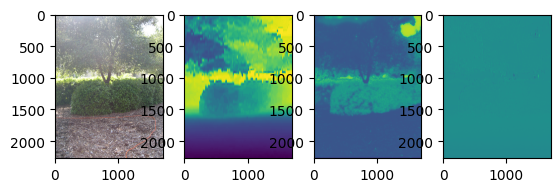

accuracy:0.029089152566132127


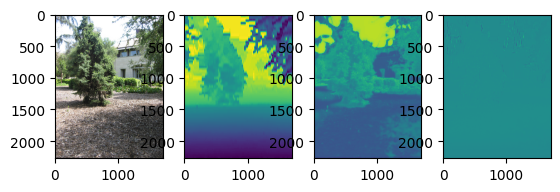

accuracy:0.028829857124078855


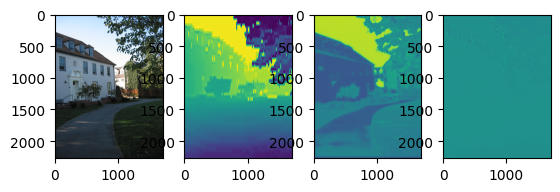

[Loss Breakdown] L1: 0.2761, SSIM: 0.0337
Batch:  1/ 50          Loss  0.309823           3/10
[Loss Breakdown] L1: 0.3115, SSIM: 0.0271
Batch:  2/ 50          Loss  0.338669           3/10
[Loss Breakdown] L1: 0.2798, SSIM: 0.0231
Batch:  3/ 50          Loss  0.302950           3/10
[Loss Breakdown] L1: 0.2819, SSIM: 0.0189
Batch:  4/ 50          Loss  0.300804           3/10
[Loss Breakdown] L1: 0.2718, SSIM: 0.0132
Batch:  5/ 50          Loss  0.285020           3/10
[Loss Breakdown] L1: 0.2553, SSIM: 0.0081
Batch:  6/ 50          Loss  0.263388           3/10
[Loss Breakdown] L1: 0.2584, SSIM: 0.0046
Batch:  7/ 50          Loss  0.262999           3/10
[Loss Breakdown] L1: 0.2787, SSIM: -0.0033
Batch:  8/ 50          Loss  0.275458           3/10
[Loss Breakdown] L1: 0.2682, SSIM: -0.0066
Batch:  9/ 50          Loss  0.261586           3/10
[Loss Breakdown] L1: 0.2603, SSIM: -0.0127
Batch: 10/ 50          Loss  0.247634           3/10
[Loss Breakdown] L1: 0.2435, SSIM: -0.0170
Batc

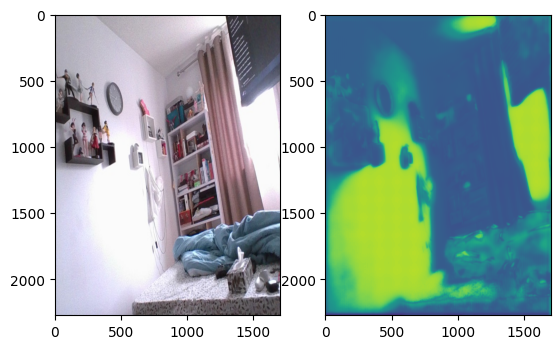

accuracy:0.020982311875460416


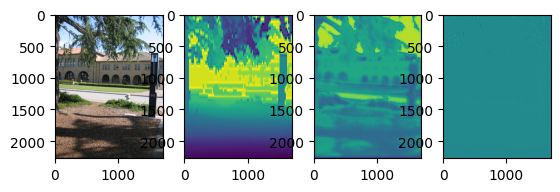

accuracy:0.024827752211352458


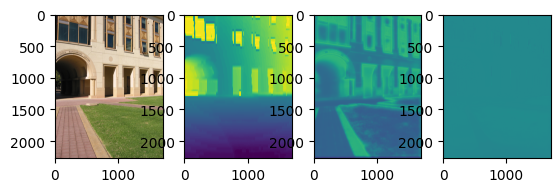

accuracy:0.020197115579717498


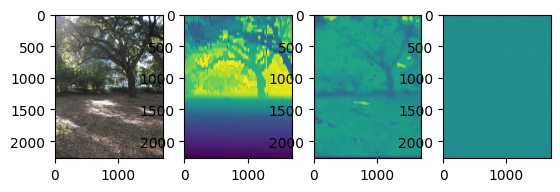

accuracy:0.02289542165722774


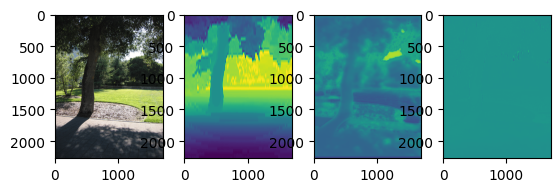

accuracy:0.02157047109692679


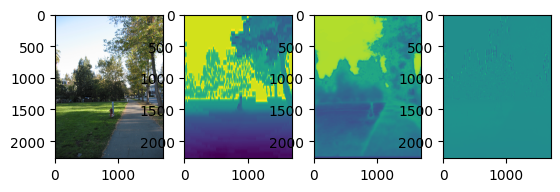

accuracy:0.022752625728297518


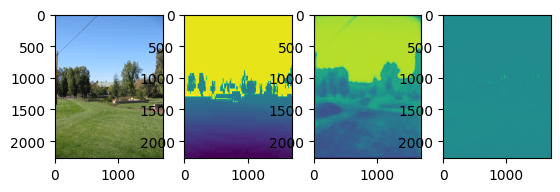

accuracy:0.02320591586194456


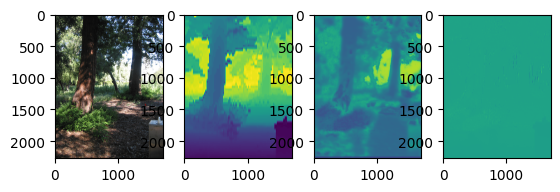

accuracy:0.023058765605799773


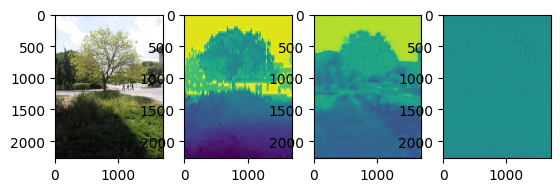

[Loss Breakdown] L1: 0.1657, SSIM: -0.2235
Batch:  1/ 50          Loss -0.057808           4/10
[Loss Breakdown] L1: 0.1580, SSIM: -0.2273
Batch:  2/ 50          Loss -0.069271           4/10
[Loss Breakdown] L1: 0.1665, SSIM: -0.2339
Batch:  3/ 50          Loss -0.067395           4/10
[Loss Breakdown] L1: 0.1770, SSIM: -0.2400
Batch:  4/ 50          Loss -0.063086           4/10
[Loss Breakdown] L1: 0.1510, SSIM: -0.2432
Batch:  5/ 50          Loss -0.092141           4/10
[Loss Breakdown] L1: 0.1381, SSIM: -0.2474
Batch:  6/ 50          Loss -0.109287           4/10
[Loss Breakdown] L1: 0.1434, SSIM: -0.2537
Batch:  7/ 50          Loss -0.110251           4/10
[Loss Breakdown] L1: 0.1433, SSIM: -0.2591
Batch:  8/ 50          Loss -0.115749           4/10
[Loss Breakdown] L1: 0.1474, SSIM: -0.2650
Batch:  9/ 50          Loss -0.117539           4/10
[Loss Breakdown] L1: 0.1376, SSIM: -0.2689
Batch: 10/ 50          Loss -0.131243           4/10
[Loss Breakdown] L1: 0.1440, SSIM: -0.27

KeyboardInterrupt: 

In [ ]:
train(model,train_dataloader,optimizer,loss,scheduler,epochs=range(10),model_name="sigmoid_loses")

In [ ]:
# file_name = "implemented_only_make3d"
# torch.save(model,f"./models/saved/{file_name}.pb")
# torch.save(model.state_dict(),f"./models/saved/{file_name}_state.pth")

In [ ]:
model.eval()

In [ ]:
print(torch.cuda.memory_summary())

In [ ]:
compareResults(model,train_dataloader,num_batches=1)

In [ ]:
path = "./models/checkpoints/implemented_only_make3d_19.pth"
model2 = EncoderDecoder()
dict_load = torch.load(path,weights_only=False)
model2.load_state_dict(dict_load["model_state_dict"])
model2.to(device)

In [ ]:
compareResults(model2,val_dataloader,num_batches=2)

In [ ]:
del model2

# Loading another data set*
*may not be completed

In [ ]:
model = EncoderDecoder()
model.to(device)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20,gamma=0.5)

In [ ]:
loss = l1_ssim_loss

In [ ]:
train(model,concat_train_dataloader,val_dataloader,optimizer,loss,scheduler,epochs=25)

In [ ]:
file_name = "concatenated"
torch.save(model,f"./models/saved/{file_name}.pb")
torch.save(model.state_dict(),f"./models/saved/{file_name}_state.pth")

In [ ]:
model.eval()

In [ ]:
compareResults(model,val_dataloader,num_batches=2)